# WDRO

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
loaded_pipeline = joblib.load('../jobs/preprocessing.joblib')
loaded_model = joblib.load('../jobs/logistic_regression_PCA_model.joblib')
data = pd.read_csv('../data/rt_iot2022.csv')

In [3]:
X = data.drop('Attack_type', axis=1)
y = data['Attack_type']

from sklearn.preprocessing import OneHotEncoder

categorical_feature = ['proto', 'service']
onehot = OneHotEncoder(sparse_output = False)
encoded_categorical = onehot.fit_transform(data[categorical_feature])

encoded_df = pd.DataFrame(encoded_categorical, columns = onehot.get_feature_names_out(categorical_feature))
X_encoded = X.drop(categorical_feature, axis = 1)
X_encoded = pd.concat([X_encoded, encoded_df], axis = 1)
X_encoded.head()

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,38667,1883,32.011598,9,5,3,3,0.281148,0.156193,0.437341,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,51143,1883,31.883584,9,5,3,3,0.282277,0.156821,0.439097,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,44761,1883,32.124053,9,5,3,3,0.280164,0.155647,0.435811,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,60893,1883,31.961063,9,5,3,3,0.281593,0.156440,0.438033,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,51087,1883,31.902362,9,5,3,3,0.282111,0.156728,0.438839,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [4]:
from sklearn.model_selection import train_test_split
X_preprocessed = loaded_pipeline.transform(X_encoded)
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state = 42)

In [6]:
from skwdro.linear_models import LogisticRegression as skwdroLogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rhos = [10**i for i in range(-5, 0)]
classifiers = []

for rho in rhos:
    classifiers.append(skwdroLogisticRegression(rho=rho, learning_rate=1e-3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



for i in range(len(classifiers)):
    classifiers[i].fit(X_train_scaled, y_train)
    y_pred = classifiers[i].predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    #adv = calculate_adversarial_accuracy(classifiers[i], X_test_scaled, y_test, eps=0.1)
    print(f"Rho: {rhos[i]:.6f} => Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.000010 => Accuracy: 0.977, Precision: 0.976, Recall: 0.977, F1: 0.975


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.000100 => Accuracy: 0.969, Precision: 0.968, Recall: 0.969, F1: 0.967


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.001000 => Accuracy: 0.966, Precision: 0.966, Recall: 0.966, F1: 0.965


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.010000 => Accuracy: 0.933, Precision: 0.946, Recall: 0.933, F1: 0.926


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.100000 => Accuracy: 0.908, Precision: 0.885, Recall: 0.908, F1: 0.890


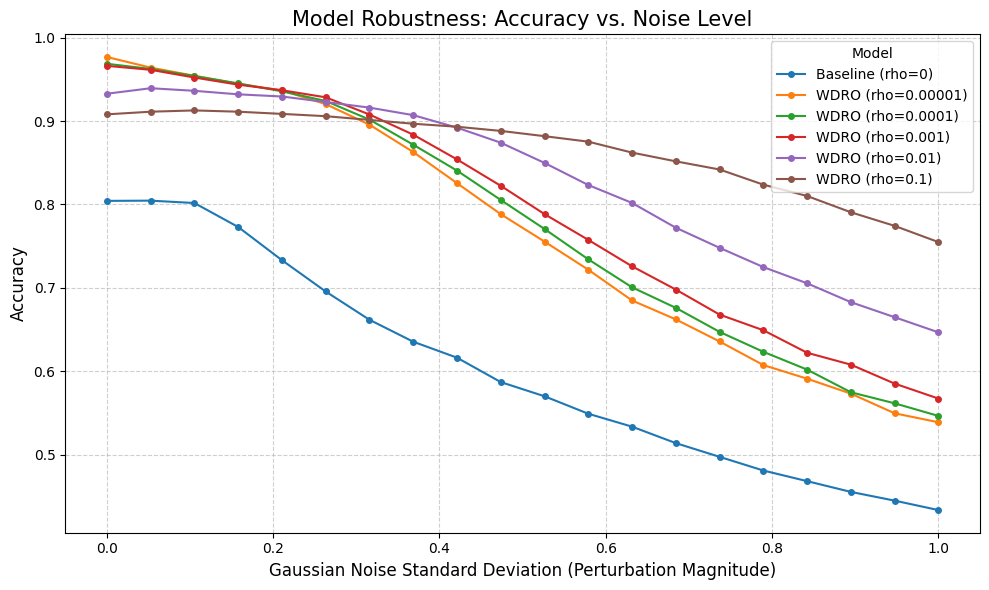

In [ ]:
def generate_noisy_data(X_test, noise_std):
    """Adds Gaussian noise to the test data."""
    noise = np.random.normal(0, noise_std, X_test.shape)
    return X_test + noise

def plot_stability(models_dict, X_test, y_test):
    """
    Generates and plots the stability curve for multiple models.

    Args:
        models_dict (dict): A dictionary of {'Label': trained_model_instance}.
        X_test (np.ndarray): The clean test features.
        y_test (np.ndarray): The test labels.
    """
    
    # Define the range of noise levels (standard deviation of the Gaussian noise)
    noise_levels = np.linspace(0.0, 1.0, 20) # 0.0 (clean) to 1.0 (very noisy)
    
    plt.figure(figsize=(10, 6))
    
    for label, model in models_dict.items():
        accuracies = []
        for std in noise_levels:
            # 1. Generate noisy data
            X_test_noisy = generate_noisy_data(X_test, std)
            
            # 2. Predict and calculate accuracy
            y_pred = model.predict(X_test_noisy)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)
        
        # 3. Plot the stability curve
        plt.plot(noise_levels, accuracies, label=label, marker='o', markersize=4)

    # --- Plot Formatting ---
    plt.title('Model Robustness: Accuracy vs. Noise Level', fontsize=15)
    plt.xlabel('Gaussian Noise Standard Deviation (Perturbation Magnitude)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(title='Model', loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Group your models for plotting
models_to_test = {
    'Baseline (rho=0)': loaded_model,
    'WDRO (rho=0.00001)': classifiers[0],
    'WDRO (rho=0.0001)': classifiers[1],
    'WDRO (rho=0.001)': classifiers[2],
    'WDRO (rho=0.01)': classifiers[3],
    'WDRO (rho=0.1)': classifiers[4], 
}

# The most robust model will have the flattest line (least degradation)
plot_stability(models_to_test, X_test_scaled, y_test)